:::{admonition} Run this notebook yourself!
:class: important

Download the executed notebook: **{nb-download}`ds_vlines.ipynb`**!

Run it in your browser: **{binder}`ds_vlines.ipynb`**!

:::

# vlines

In this notebook, we will create a datasaurus metamer shaped like multiple vertical lines.

This notebook is intentionally brief: most of the code is hidden (you can expand the cells if you would like to see more details), and we only explain the penalty. See [](datasaurus-index) for an overview of the datasaurus dozen dataset.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import torch

import plenoptic as po

# so that relative sizes of axes created by po.plot.imshow and others look right
plt.rcParams["figure.dpi"] = 72

plt.rcParams["animation.html"] = "html5"
# use single-threaded ffmpeg for animation writer
plt.rcParams["animation.writer"] = "ffmpeg"
plt.rcParams["animation.ffmpeg_args"] = ["-threads", "1"]
plt.rcParams["savefig.bbox"] = "tight"

po.set_seed(0)
# To guarantee reproducibility for this example on the GPU, we must tell torch to use
# deterministic algorithms. Note this will make things slower! See "Reproducibility and
# Compatibility" in the docs for more details.
torch.use_deterministic_algorithms(True)


# Model definition, as in top-level notebook
class DatasaurusModel(torch.nn.Module):
    def __init__(self, n_pts=None, dtype=None):
        """
        Create model to measure datasaurus stats.

        Parameters
        ----------
        n_pts
            Number of data points in the dataset we'll use the model for. Used to cache
            a corresponding vector of ones for computing linear regression.
        dtype
            dtype for the dataset we'll use the model for. Used to cache
            a corresponding vector of ones for computing linear regression.
        """
        super().__init__()
        # cache ones to save time
        if n_pts is not None:
            self._ones = torch.ones(n_pts, dtype=dtype)
        else:
            self._ones = None
        # This model has no trainable parameters, so it's always in eval mode
        self.eval()

    def _prepare_X(self, x):
        """Append vector of ones to matrix for linear regression (for intercept)."""
        ones = self._ones if self._ones is None else torch.ones_like(x)
        return torch.stack([ones, x], -1)

    def _compute_linreg(self, x, y):
        """Compute linear regression (with intercept) between x and y."""
        X = self._prepare_X(x)
        # unsqueezing and squeezing needed because of https://github.com/pytorch/pytorch/issues/158169
        return torch.linalg.lstsq(X, y.unsqueeze(-1)).solution.squeeze()

    def _compute_coeff_determination(self, x, y, solution):
        """Compute R^2 for linera regression fit."""
        X = self._prepare_X(x)
        pred_y = torch.einsum("x, n x -> n", solution, X)
        ss_res = (y - pred_y).pow(2).sum()
        ss_tot = (y - y.mean()).pow(2).sum()
        return 1 - (ss_res / ss_tot)

    def _vmap_coeff_determination(self, x, solution):
        """vmap _compute_coeff_determiniation across dim=0."""
        f = torch.func.vmap(lambda x, solt: self._compute_coeff_determination(*x, solt))
        return f(x, solution).unsqueeze(-1)

    def forward(self, data):
        """Compute summary statistics on data."""
        if data.ndim == 2:
            data = data.unsqueeze(0)
        elif data.ndim != 3:
            raise ValueError("data must be 2 or 3d!")
        stats = []
        stats.append(data.mean(-1))
        stats.append(data.std(-1))
        solution = torch.func.vmap(lambda x: self._compute_linreg(*x))(data)
        stats.append(solution)
        crosscorr = torch.func.vmap(lambda x: torch.corrcoef(x)[0, 1])(data)
        stats.append(crosscorr.unsqueeze(-1))
        stats.append(self._vmap_coeff_determination(data, solution))
        return torch.cat(stats, -1)

    def plot_representation(self, data, ax=None, style="stem", figsize=(6, 3)):
        """
        Plot model representation of data.

        We plot the representation as stem plots (if style=="stem") or dashed
        horizontal lines (if style=="lines"), on two separate sub-axes. The grouping
        is determined by their approximate magnitude in the original dino dataset. The
        first contains ["x mean", "y mean", "x std", "y std", "linreg intercept"], while
        the second contains ["linreg slope", "correlation", and "R^2"].

        Parameters
        ----------
        data: torch.Tensor
            The data to show on the plot. Should look like the output of
            forward, with the exact same structure.
        ax: plt.Axes or None
            Axes where we will plot the data. If a plt.Axes instance, will
            subdivide into 2 new axes. If None, we create a new figure.
        style: {"stem", "lines"}
            If "stem", plot data as stem plot. If "lines", plot as dashed
            horizontal lines.
        figsize: tuple[int]
            The size of the figure to create. Ignored if ax is not None.

        Returns
        -------
        axes
            List of two axes containing the subplots.
        """
        data = po.to_numpy(data).squeeze()
        # Set up grid spec
        if ax is None:
            # we add 2 to order because we're adding one to get the
            # number of orientations and then another one to add an
            # extra column for the mean luminance plot
            fig = plt.figure(figsize=figsize, layout="constrained")
            gs = mpl.gridspec.GridSpec(1, 2, fig, width_ratios=[5, 3])
            axes = [fig.add_subplot(gs[0, i]) for i in range(2)]
        elif isinstance(ax, mpl.axes.Axes) or len(ax) == 1:
            # want to make sure the axis we're taking over is basically invisible.
            ax = po.plot.display._clean_up_axes(
                ax, False, ["top", "right", "bottom", "left"], ["x", "y"]
            )
            gs = ax.get_subplotspec().subgridspec(1, 2, width_ratios=[5, 3])
            fig = ax.figure
            axes = [fig.add_subplot(gs[0, i]) for i in range(2)]
        else:
            axes = ax
            fig = axes[0].figure

        labels = [
            "x mean",
            "y mean",
            "x std",
            "y std",
            "linreg intercept",
            "linreg slope",
            "correlation",
            "$R^2$",
        ]
        cutoff = 5
        linewidth = 1
        for i, ax in enumerate(axes):
            if i == 0:
                slicer = slice(0, cutoff)
            elif i == 1:
                slicer = slice(cutoff, len(labels) + 1)
            y = data[slicer]
            labs = labels[slicer]
            x = np.arange(len(labs))

            if style == "stem":
                ax.stem(y)
            elif style == "lines":
                ax.hlines(y, x - linewidth / 2, x + linewidth / 2, "k", "--")
            ax.set_xticks(x, labs, rotation=30, ha="right")
        return axes

The following plot shows the `v_lines` dataset from the original datasaurus dozen, along with its representation.

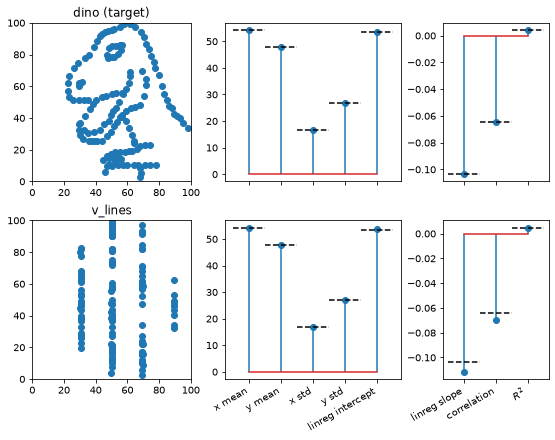

In [2]:
data = torch.load(po.data.fetch_data("datasaurus.tar.gz") / "datasaurus.pt")
categories = np.load(
    po.data.fetch_data("datasaurus.tar.gz") / "categories.npy", allow_pickle=True
)

model = DatasaurusModel(data.shape[1], data.dtype)

fig, axes = plt.subplots(
    2, 3, figsize=(8, 6), width_ratios=[5, 5, 3], layout="compressed"
)
for i, title in enumerate(["dino (target)", "v_lines"]):
    d = data[categories == title].squeeze()
    axes[i, 0].scatter(*d)
    axes[i, 0].set_title(title)
    axes[i, 0].set(xlim=(0, 100), ylim=(0, 100))
    axes[i, 0].set_aspect(1)
    model.plot_representation(model(d), axes[i, 1:])
    model.plot_representation(model(data)[0], axes[i, 1:], "lines")
    if i == 0:
        axes[i, 1].set(xticklabels=[])
        axes[i, 2].set(xticklabels=[])

Our intended shape here, as can be seen above, is four vertical lines, roughly evenly distributed across the right two-thirds of the plot. To encourage metamer synthesis to find such a dataset, we create several functions (all of these show up in other notebooks in this series and so may look familiar):
- `predict_line` returns the y-values for a user-defined line, evaluated at the specified x-values.
- `lines_penalty` returns the mean-squared error for a set of points, given a user-specified set of slopes and intercepts. This function arbitrarily splits the data into one group per intercept.
- `vlines_penalty` ensures that the input arguments are the proper type and shape, then calls `lines_penalty`.

To use this penalty with synthesis, we define the x-values of the vertical lines (try changing these to different values!) and combine the resulting value with a range penalty which requires all points to lie between 0 and 100.

:::{admonition} Other slopes/intercepts
:class: seealso

You can see how other combinations of slopes and intercepts lead to different shapes in:  [](ds_hlines.md), [](ds_vlines.md), [](ds_slantup.md), and [](ds_slantdown.md).

:::

In [3]:
def predict_line(x_vals, intercepts, slope):
    return slope * x_vals + intercepts


def lines_penalty(data, intercepts, slope):
    # intercepts must be shape [n, 1], slope a scalar or same number of elements as
    # intercepts
    errors = []
    n = data.shape[-1] // intercepts.shape[0]
    # Must either have the same number of slopes and intercepts...
    if hasattr(slope, "__len__") and len(slope) != 1:
        assert len(slope) == len(intercepts)
    else:
        # ...or one intercept
        slope = len(intercepts) * [slope]
    for i, (inter, sl) in enumerate(zip(intercepts, slope)):
        # split data arbitrarily
        if i != len(intercepts) - 1:
            split = data[..., i * n : (i + 1) * n]
        else:
            # last iteration may have extra entries
            split = data[..., i * n :]
        pred_y = predict_line(split[0], inter, sl)
        errors.append((split[1] - pred_y).pow(2))
    return torch.mean(torch.cat(errors))


def vlines_penalty(data, x_vals):
    intercepts = torch.as_tensor(x_vals).unsqueeze(-1)
    # same as hlines, except we swap x and y:
    return lines_penalty(data[[1, 0]], intercepts, 0)


# Try changing this to other values!
x_vals = [30, 50, 70, 90]


def penalty(x):
    range_penalty = po.regularize.penalize_range(x, (0, 100))
    vlines = vlines_penalty(x, x_vals)
    return range_penalty + vlines


# data[0] is the dinosaur
met = po.Metamer(data[0], model, penalty_function=penalty, penalty_lambda=0.0005)
met.setup(initial_image=100 * torch.rand_like(data[0]), optimizer=torch.optim.LBFGS)
met.synthesize(50, store_progress=True)

/home/jenkins/agent/workspace/CCN_neurorse_plenoptic_PR-492/lib/python3.12/site-packages/plenoptic/validate.py:101: UserWarning: plenoptic's methods have mostly been tested on 4d inputs with shape torch.Size([n_batch, n_channels, im_height, im_width]). They should theoretically work with different dimensionality; if you have any problems, please open an issue at https://github.com/plenoptic-org/plenoptic/issues/new?template=bug_report.md
  warnings.warn(
/home/jenkins/agent/workspace/CCN_neurorse_plenoptic_PR-492/lib/python3.12/site-packages/plenoptic/validate.py:116: UserWarning: input_tensor range is (2.9487, 99.4872); plenoptic's methods have largely been tested with the range [0, 1]. Synthesis should still work, but if you have any problems, please open an issue.
  warnings.warn(
/home/jenkins/agent/workspace/CCN_neurorse_plenoptic_PR-492/lib/python3.12/site-packages/plenoptic/validate.py:116: UserWarning: input_tensor range is (0.06377352878489395, 99.71721216879205); plenoptic's 

  0%|          | 0/50 [00:00<?, ?it/s]

In [4]:
# use one of our helper functions here.
from plenoptic.plot.display import _update_stem

# Initialize figure by plotting the first iteration
fig, axes = plt.subplots(
    1, 3, figsize=(8, 3), width_ratios=[5, 5, 3], layout="compressed"
)
plot_data = met.saved_metamer
ani_data = po.to_numpy(plot_data)
ani_rep = po.to_numpy(model(plot_data))
path = axes[0].scatter(*ani_data[0])
ys = np.asarray([0, 100])
for x in x_vals:
    axes[0].plot(predict_line(ys, x, 0), ys, "k--", zorder=0)
axes[0].set(xlim=(0, 100), ylim=(0, 100))
axes[0].set_aspect(1)

rep_axes = model.plot_representation(model(data)[0], axes[1:], "lines")
model.plot_representation(ani_rep[0], rep_axes)
fig.set_layout_engine("none")


# Update the data for each saved iteration.
def animate(i):
    path.set_offsets(ani_data[i].T)
    _update_stem(rep_axes[0].containers[0], ani_rep[i, :5])
    _update_stem(rep_axes[1].containers[0], ani_rep[i, 5:])


ani = mpl.animation.FuncAnimation(fig, animate, range(len(plot_data)), repeat=False)
plt.close(fig)
ani

In the video of the synthesis above, we can see the dataset first shifting itself to become metameric, before moving the points around and then condensing into vertical lines. However, like [](ds_circle.md), the points do not land exactly on their targets. Analagously to [](ds_circle.md), the points do form perfect vertical lines, but their x-values do not align exactly with the targets.

Remember that the tradeoff between the metamer objective and the penalty is [governed by {attr}`~plenoptic.Metamer.penalty_lambda`](penalty-lambda): if we increased {attr}`~plenoptic.Metamer.penalty_lambda` in the above block, we could make the synthesis procedure push the points onto the specified locations at the cost of reducing the metamer quality. Alternatively, we could also change the penalty so as to exclude some small number of points, allowing them to move freely, which might allow the other points to match the target locations more closely.

In [5]:
import os

from plenoptic.tensors import _check_tensor_equality

if os.environ.get("DATASAURUS_CHECK", False):
    # This cell just tests for reproducibility. As a user, you should skip it -- because
    # pytorch doesn't guarantee reproducibility across CPU/GPU and GPU types, it's
    # unlikely that your results will exactly match ours. (Though it should look
    # approximately as good -- if not, open an issue!)
    cached_met = (
        po.data.fetch_data("datasaurus_metamers.tar.gz") / "datasaurus-vlines.pt"
    )
    # just load in the metamer tensor, instead of the whole object
    cached_met = torch.load(cached_met)["_metamer"]
    _check_tensor_equality(
        met.metamer,
        cached_met,
        "Notebook",
        "OSF",
        1e-5,
        1e-7,
        "metamer has different {error_type}! Update the OSF version.",
    )